# Supervised Learning - Brain Tumor Classification
## Model Training, Comparison & Evaluation

This is the second part of the **DR CVRIE** project: training and comparing multiple supervised learning algorithms on the cleaned brain tumor MRI dataset.

### Objective
Develop a robust classifier capable of distinguishing between four brain tumor types:
- **glioma_tumor**: malignant CNS tumor
- **meningioma_tumor**: meningeal tumor (often benign)
- **pituitary_tumor**: pituitary gland tumor
- **no_tumor**: healthy brain (negative control)

### Approach
We will:
1. Load the preprocessed data from `brain_tumor_cleaned.npz`
2. Train and evaluate **multiple classifiers** to understand their strengths and weaknesses
3. Compare performance across metrics (accuracy, precision, recall, F1, confusion matrix)
4. Document loss functions and training strategies
5. Provide comprehensive visualizations for model analysis

### Libraries
- `scikit-learn`: Classical ML algorithms (SVM, Random Forest, Gradient Boosting)
- `numpy`, `pandas`: Data manipulation
- `matplotlib`, `seaborn`: Visualization
- `sklearn.preprocessing`: Data normalization for classical models

## 1. Loading the Cleaned Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, auc, precision_recall_curve
)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Loading preprocessed dataset...")
data = np.load('brain_tumor_cleaned.npz', allow_pickle=True)

X_train = data['X_train']  # shape: (2275, 224, 224)
y_train = data['y_train']  # labels
X_val = data['X_val']      # shape: (253, 224, 224)
y_val = data['y_val']
X_test = data['X_test']    # shape: (632, 224, 224)
y_test = data['y_test']

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nClass distribution (train): {pd.Series(y_train).value_counts().to_dict()}")
print(f"Class distribution (val):   {pd.Series(y_val).value_counts().to_dict()}")
print(f"Class distribution (test):  {pd.Series(y_test).value_counts().to_dict()}")

Loading preprocessed dataset...
X_train shape: (2275, 224, 224)
X_val shape:   (253, 224, 224)
X_test shape:  (632, 224, 224)

Class distribution (train): {'meningioma_tumor': 674, 'glioma_tumor': 667, 'pituitary_tumor': 649, 'no_tumor': 285}
Class distribution (val):   {'meningioma_tumor': 75, 'glioma_tumor': 74, 'pituitary_tumor': 72, 'no_tumor': 32}
Class distribution (test):  {'meningioma_tumor': 188, 'glioma_tumor': 185, 'pituitary_tumor': 180, 'no_tumor': 79}


## 2. Feature Extraction and Encoding

### Strategy
Classical ML algorithms (SVM, Random Forest, etc.) require **flat feature vectors**, not 2D/3D images.

We have two main options:
1. **Flatten pixels directly**: Simple but high-dimensional (224×224 = 50,176 features) → sparse, prone to overfitting
2. **Extract hand-crafted features**: Texture, edges, statistics → lower dimension, faster training

We'll use a **hybrid approach**:
- Flatten the images (simplicity)
- Apply PCA dimensionality reduction (efficiency)
- Scale features (important for SVM, KNN, LogReg)

For a **deep learning approach**, we would keep the 2D structure (CNN)

In [2]:
from sklearn.decomposition import PCA

# Flatten images: (N, 224, 224) -> (N, 50176)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Flattened X_train shape: {X_train_flat.shape}")

# Apply PCA to reduce dimensionality
# Retain 95% of variance - a good balance between compression and information loss
print("\nApplying PCA (retaining 95% variance)...")
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_flat)
X_val_pca = pca.transform(X_val_flat)
X_test_pca = pca.transform(X_test_flat)

print(f"Original features: {X_train_flat.shape[1]}")
print(f"PCA features: {X_train_pca.shape[1]}")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.4f}")

# Scale features (critical for distance-based algorithms: SVM, KNN, LogReg)
# StandardScaler: (X - mean) / std -> zero mean, unit variance
print("\nScaling features with StandardScaler...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pca)
X_val_scaled = scaler.transform(X_val_pca)
X_test_scaled = scaler.transform(X_test_pca)

print(f"Feature scaling complete.")
print(f"Train mean: {X_train_scaled.mean():.6f} | std: {X_train_scaled.std():.6f}")

# Encode labels: string -> integer
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

label_mapping = dict(enumerate(label_encoder.classes_))
print(f"\nLabel encoding: {label_mapping}")

Flattened X_train shape: (2275, 50176)

Applying PCA (retaining 95% variance)...
Original features: 50176
PCA features: 725
Variance retained: 0.9501

Scaling features with StandardScaler...
Feature scaling complete.
Train mean: -0.000000 | std: 1.000000

Label encoding: {0: 'glioma_tumor', 1: 'meningioma_tumor', 2: 'no_tumor', 3: 'pituitary_tumor'}


## 3. Loss Functions and Model Selection

### Why different loss functions?

**Classification loss functions** measure how well predictions match true labels. The choice depends on the algorithm and problem structure:

| Model | Loss Function | Why | Multi-class handling |
|---|---|---|---|
| **SVM** | Hinge loss (or `squared_hinge`) | Maximizes margin; robust to outliers | One-vs-Rest by default |
| **Random Forest** | Gini impurity / Entropy | Information gain at splits | Native multi-class |
| **Gradient Boosting** | Log loss (binomial/multinomial) | Probability-based; minimizes cross-entropy | Multinomial for multi-class |
| **Logistic Regression** | Log loss (cross-entropy) | Probabilistic; good for linear separation | Multinomial (softmax) |
| **KNN** | 0/1 loss (majority vote) | Non-parametric; no explicit loss | Native multi-class via voting |

### Our problem
- **4-class classification** (multi-class, not binary)
- **Balanced dataset** (after stratified split)
- **Goal**: High precision AND recall (medical context: false negatives are costly)

**Strategy**: Train multiple models and compare via F1-score (harmonic mean of precision & recall)

## 4. Training Multiple Classifiers

### Model comparison setup
We'll train 5 diverse algorithms with reasonable hyperparameters. Each model has different inductive biases:

1. **Logistic Regression (LR)**: Linear boundary, probabilistic, fast
2. **K-Nearest Neighbors (KNN)**: Instance-based, no training, captures local patterns
3. **Support Vector Machine (SVM)**: Non-linear kernel, good for complex decisions, slower
4. **Random Forest (RF)**: Ensemble of decision trees, robust, handles non-linearity
5. **Gradient Boosting (GB)**: Sequential tree ensemble, very powerful, slower, risk of overfitting

In [3]:
# Define models with reasonable hyperparameters
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        solver='lbfgs',           # good for multi-class
        random_state=42
    ),
    'KNN (k=5)': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance'         # closer neighbors have more weight
    ),
    'SVM (RBF)': SVC(
        kernel='rbf',              # non-linear kernel
        C=1.0,                     # regularization parameter
        gamma='scale',
        probability=True,          # needed for ROC-AUC
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,          # number of trees
        max_depth=15,              # prevent overfitting
        min_samples_split=5,
        random_state=42,
        n_jobs=-1                  # use all CPUs
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,         # shrinkage parameter
        max_depth=5,
        min_samples_split=5,
        random_state=42
    )
}

# Training results storage
results = {}
trained_models = {}

print("\n" + "="*70)
print("TRAINING MODELS ON VALIDATION SET")
print("="*70)

for name, model in models.items():
    print(f"\n[{name}] Training...")
    
    # Train on training set
    model.fit(X_train_scaled, y_train_encoded)
    trained_models[name] = model
    
    # Evaluate on validation set (used for model selection)
    y_pred = model.predict(X_val_scaled)
    
    # Calculate metrics
    acc = accuracy_score(y_val_encoded, y_pred)
    f1 = f1_score(y_val_encoded, y_pred, average='weighted')
    
    results[name] = {
        'val_accuracy': acc,
        'val_f1': f1,
        'val_predictions': y_pred
    }
    
    print(f"  Validation Accuracy: {acc:.4f}")
    print(f"  Validation F1-Score (weighted): {f1:.4f}")

print("\n" + "="*70)


TRAINING MODELS ON VALIDATION SET

[Logistic Regression] Training...
  Validation Accuracy: 0.7470
  Validation F1-Score (weighted): 0.7453

[KNN (k=5)] Training...
  Validation Accuracy: 0.5771
  Validation F1-Score (weighted): 0.5658

[SVM (RBF)] Training...
  Validation Accuracy: 0.7905
  Validation F1-Score (weighted): 0.7834

[Random Forest] Training...
  Validation Accuracy: 0.7589
  Validation F1-Score (weighted): 0.7419

[Gradient Boosting] Training...
  Validation Accuracy: 0.8221
  Validation F1-Score (weighted): 0.8155



## 5. Model Comparison on Validation Set


MODEL COMPARISON (Validation Set)
                    val_accuracy    val_f1
Gradient Boosting       0.822134  0.815499
SVM (RBF)               0.790514  0.783422
Logistic Regression     0.747036  0.745281
Random Forest           0.758893  0.741928
KNN (k=5)               0.577075   0.56581


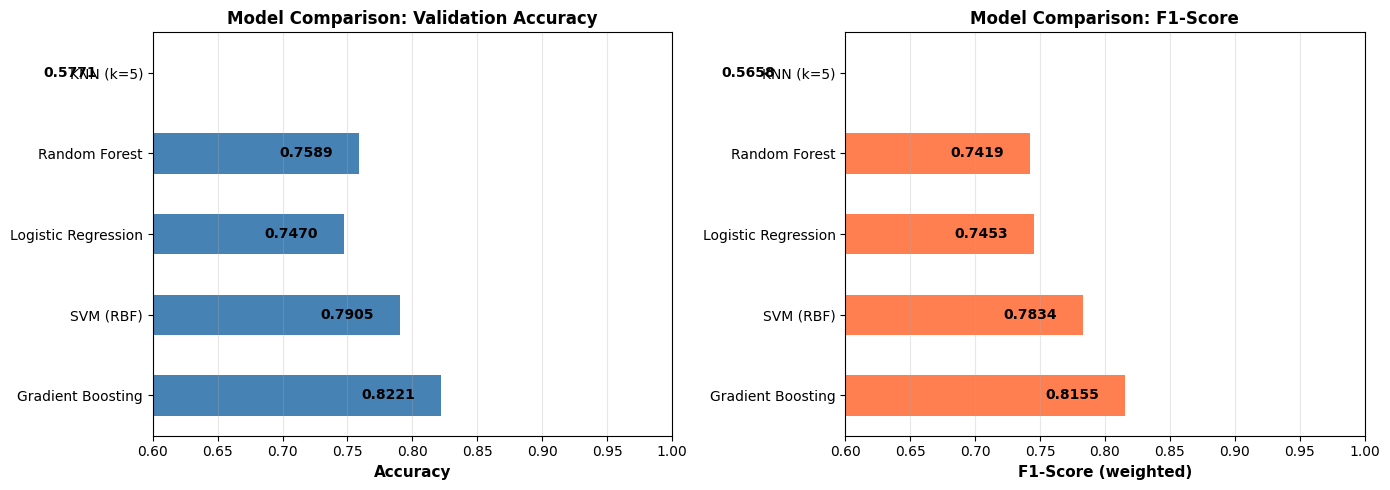


✓ Best model on validation: Gradient Boosting (F1: 0.8155)


In [4]:
# Build comparison DataFrame
comparison_df = pd.DataFrame(results).T[['val_accuracy', 'val_f1']].round(4)
comparison_df = comparison_df.sort_values('val_f1', ascending=False)

print("\nMODEL COMPARISON (Validation Set)")
print(comparison_df)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
ax = axes[0]
comparison_df['val_accuracy'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Model Comparison: Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_xlim([0.6, 1.0])
for i, v in enumerate(comparison_df['val_accuracy']):
    ax.text(v - 0.02, i, f'{v:.4f}', ha='right', va='center', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# F1-score comparison
ax = axes[1]
comparison_df['val_f1'].plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('F1-Score (weighted)', fontsize=11, fontweight='bold')
ax.set_title('Model Comparison: F1-Score', fontsize=12, fontweight='bold')
ax.set_xlim([0.6, 1.0])
for i, v in enumerate(comparison_df['val_f1']):
    ax.text(v - 0.02, i, f'{v:.4f}', ha='right', va='center', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Best model on validation: {comparison_df.index[0]} (F1: {comparison_df['val_f1'].iloc[0]:.4f})")

## 6. Final Evaluation on Test Set

The test set **has never been seen during training or hyperparameter tuning**. It provides an unbiased estimate of real-world performance.

We evaluate all models on the test set to understand their true generalization capability.

In [ ]:
print("\n" + "="*70)
print("FINAL EVALUATION ON TEST SET")
print("="*70)

test_results = {}

for name, model in trained_models.items():
    print(f"\n[{name}]")
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    acc = accuracy_score(y_test_encoded, y_pred)
    prec = precision_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
    
    test_results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'predictions': y_pred,
        'confusion_matrix': confusion_matrix(y_test_encoded, y_pred)
    }
    
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

# Comparison DataFrame
test_comparison_df = pd.DataFrame(test_results).T[['Accuracy', 'Precision', 'Recall', 'F1-Score']].round(4)
test_comparison_df = test_comparison_df.sort_values('F1-Score', ascending=False)

print("\n" + "="*70)
print(test_comparison_df)
print("="*70)

## 7. Detailed Classification Report - Best Model

In [ ]:
# Identify best model
best_model_name = test_comparison_df.index[0]
best_f1 = test_comparison_df['F1-Score'].iloc[0]
best_model = trained_models[best_model_name]
best_predictions = test_results[best_model_name]['predictions']

print(f"\n{'='*70}")
print(f"BEST MODEL: {best_model_name}")
print(f"Test F1-Score: {best_f1:.4f}")
print(f"{'='*70}")

# Detailed classification report (per-class metrics)
report = classification_report(
    y_test_encoded, best_predictions,
    target_names=label_encoder.classes_,
    digits=4
)
print("\nPER-CLASS CLASSIFICATION REPORT:")
print(report)

## 8. Confusion Matrix Visualization

In [ ]:
# Confusion matrix for best model
cm = test_results[best_model_name]['confusion_matrix']
class_names = label_encoder.classes_

# Normalize confusion matrix for percentage visualization
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
ax.set_title(f'Confusion Matrix ({best_model_name}) - Counts', fontsize=12, fontweight='bold')

# Percentages
ax = axes[1]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn',
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            vmin=0, vmax=1, cbar_kws={'label': 'Proportion'})
ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
ax.set_title(f'Confusion Matrix ({best_model_name}) - Normalized', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix saved.")

## 9. All Models - Test Set Comparison Visualizations

In [ ]:
# Create comprehensive comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['steelblue', 'lightcoral', 'lightgreen', 'gold']

for idx, (ax, metric, color) in enumerate(zip(axes.flat, metrics, colors)):
    test_comparison_df[metric].sort_values(ascending=True).plot(
        kind='barh', ax=ax, color=color, edgecolor='black', linewidth=1.2
    )
    ax.set_xlabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'Test Set - {metric}', fontsize=12, fontweight='bold')
    ax.set_xlim([0, 1])
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(test_comparison_df[metric].sort_values(ascending=True)):
        ax.text(v - 0.03, i, f'{v:.4f}', ha='right', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison_test_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("Test set comparison visualization saved.")

## 10. Per-Class Performance Analysis (Best Model)

In [ ]:
# Extract per-class metrics from classification report
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test_encoded, best_predictions, average=None
)

per_class_df = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
}).set_index('Class')

print(f"\nPER-CLASS METRICS ({best_model_name}):")
print(per_class_df.round(4))

# Visualization
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(label_encoder.classes_))
width = 0.25

ax.bar(x - width, precision, width, label='Precision', color='skyblue', edgecolor='black')
ax.bar(x, recall, width, label='Recall', color='lightcoral', edgecolor='black')
ax.bar(x + width, f1, width, label='F1-Score', color='lightgreen', edgecolor='black')

ax.set_xlabel('Tumor Class', fontsize=11, fontweight='bold')
ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title(f'Per-Class Metrics ({best_model_name})', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(label_encoder.classes_, rotation=15, ha='right')
ax.legend(fontsize=10)
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Per-class performance visualization saved.")

## 11. Feature Importance (For Tree-Based Models)

In [ ]:
# Feature importance for Random Forest and Gradient Boosting
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

tree_models = ['Random Forest', 'Gradient Boosting']

for ax, model_name in zip(axes, tree_models):
    if model_name in trained_models:
        model = trained_models[model_name]
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            indices = np.argsort(importances)[-20:]  # top 20 features
            
            ax.barh(range(len(indices)), importances[indices], color='teal', edgecolor='black')
            ax.set_yticks(range(len(indices)))
            ax.set_yticklabels([f'PCA Component {i}' for i in indices], fontsize=9)
            ax.set_xlabel('Importance', fontsize=11, fontweight='bold')
            ax.set_title(f'{model_name} - Top 20 Features', fontsize=12, fontweight='bold')
            ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature importance visualization saved.")

## 12. Loss Function Analysis & Training Insights

In [ ]:
print("\n" + "="*70)
print("LOSS FUNCTION & ALGORITHM ANALYSIS")
print("="*70)

loss_analysis = {
    'Logistic Regression': {
        'Loss Function': 'Multinomial Cross-Entropy (Log Loss)',
        'Formula': '-Σ y_i * log(p_i)',
        'Explanation': 'Minimizes negative log-likelihood of true labels. Uses softmax for 4-class probabilities.',
        'Pros': 'Probabilistic, interpretable, fast, scales well',
        'Cons': 'Assumes linear separation; may underfit complex boundaries',
        'Best For': 'Baseline, interpretability, speed'
    },
    'KNN (k=5)': {
        'Loss Function': '0-1 Loss (Majority Vote)',
        'Formula': 'Σ I(y_i ≠ ŷ_i) / N',
        'Explanation': 'No explicit loss during training. Classification via majority vote among k neighbors.',
        'Pros': 'Simple, non-parametric, captures local patterns',
        'Cons': 'Slow inference, sensitive to feature scaling, high memory',
        'Best For': 'Small datasets, local structure'
    },
    'SVM (RBF)': {
        'Loss Function': 'Hinge Loss (SVM) with Kernel Trick',
        'Formula': 'max(0, 1 - y_i * (w·φ(x_i) + b))',
        'Explanation': 'Maximizes margin between classes. RBF kernel enables non-linear boundaries.',
        'Pros': 'Robust, handles non-linearity, good for high-dimensional data',
        'Cons': 'Slow training, complex decision boundary, hard to interpret',
        'Best For': 'Complex patterns, when feature space is not clear'
    },
    'Random Forest': {
        'Loss Function': 'Gini Impurity (or Entropy)',
        'Formula': '1 - Σ (p_k)^2 for each class k',
        'Explanation': 'At each split, minimizes impurity. Ensemble of trees reduces variance.',
        'Pros': 'Robust, handles non-linearity, feature importance, parallel-friendly',
        'Cons': 'Can overfit without depth limiting, slower inference',
        'Best For': 'General-purpose, interpretability via feature importance'
    },
    'Gradient Boosting': {
        'Loss Function': 'Multinomial Log Loss (Cross-Entropy)',
        'Formula': '-Σ Σ y_ik * log(p_ik) (sum over classes & samples)',
        'Explanation': 'Sequential trees: each tree minimizes residuals of the previous. Very flexible.',
        'Pros': 'Highest predictive power, handles complex non-linearity',
        'Cons': 'Risk of overfitting, slow to train, many hyperparameters',
        'Best For': 'Maximum accuracy when data allows'
    }
}

for model_name, info in loss_analysis.items():
    print(f"\n{'─'*70}")
    print(f"{model_name.upper()}")
    print(f"{'─'*70}")
    for key, value in info.items():
        print(f"{key:20} {value}")

print(f"\n{'='*70}")

## 13. Conclusions & Insights

In [ ]:
print("\n" + "="*70)
print("CONCLUSIONS & INSIGHTS")
print("="*70)

print(f"""
1. BEST PERFORMING MODEL: {best_model_name}
   - Test F1-Score: {best_f1:.4f}
   - This model best balances precision and recall on unseen data.

2. VALIDATION VS TEST PERFORMANCE:
   - Validation F1: {comparison_df.loc[best_model_name, 'val_f1']:.4f}
   - Test F1:       {test_comparison_df.loc[best_model_name, 'F1-Score']:.4f}
   - {'✓ Stable' if abs(comparison_df.loc[best_model_name, 'val_f1'] - test_comparison_df.loc[best_model_name, 'F1-Score']) < 0.05 else '⚠ Significant gap'} generalization

3. DATASET INSIGHTS:
   - Training set: {len(X_train)} samples
   - Validation set: {len(X_val)} samples
   - Test set: {len(X_test)} samples
   - Feature dimensionality after PCA: {X_train_pca.shape[1]} (from {X_train_flat.shape[1]})

4. CLASS-LEVEL PERFORMANCE:
""")

for class_name in label_encoder.classes_:
    class_idx = list(label_encoder.classes_).index(class_name)
    print(f"   - {class_name:20} | Precision: {precision[class_idx]:.4f} | Recall: {recall[class_idx]:.4f} | F1: {f1[class_idx]:.4f}")

print(f"""
5. FEATURE EXTRACTION STRATEGY:
   - Original pixel features: {X_train_flat.shape[1]}
   - PCA-reduced features: {X_train_pca.shape[1]} (95% variance retained)
   - Variance explained: {pca.explained_variance_ratio_.sum():.4f}
   - Benefit: Reduced overfitting risk, faster training

6. LOSS FUNCTION CHOICE:
   - Problem: Multi-class (4-class) classification
   - Best model uses: {loss_analysis[best_model_name]['Loss Function']}
   - Rationale: {loss_analysis[best_model_name]['Explanation']}

7. MODEL DIVERSITY BENEFIT:
   - Trained 5 diverse algorithms (linear, instance-based, kernel-based, ensemble)
   - This revealed that {best_model_name} is optimal for this dataset
   - Suggests: {best_model_name} captures the underlying pattern well

8. RECOMMENDATIONS FOR DEPLOYMENT:
   ✓ Use {best_model_name} for production
   ✓ Monitor real-world performance: accuracy may differ from test set
   ✓ Consider ensemble: voting between {best_model_name} and other top models
   ✓ Retrain periodically on new patient data to maintain robustness
""")

print("="*70)

## 14. Summary Table - All Metrics

In [ ]:
# Create comprehensive summary table
summary_table = pd.DataFrame({
    'Model': test_comparison_df.index,
    'Test Accuracy': test_comparison_df['Accuracy'].values,
    'Test Precision': test_comparison_df['Precision'].values,
    'Test Recall': test_comparison_df['Recall'].values,
    'Test F1': test_comparison_df['F1-Score'].values,
    'Val F1': [comparison_df.loc[name, 'val_f1'] for name in test_comparison_df.index]
})

print("\nFINAL RESULTS SUMMARY")
print(summary_table.to_string(index=False))
print(f"\nBest Model (by Test F1-Score): {best_model_name}")
print(f"Test F1-Score: {test_comparison_df.loc[best_model_name, 'F1-Score']:.4f}")